In [1]:
import demes
import msprime
import tszip
import numpy as np
import pandas as pd
import yaml
from tqdm import tqdm
from workflow.scripts.utils import Analysis_workflow_utils
from arg_hmm.arg_hmm import GhostProductHmm, GhostFixedHmm
from arg_hmm.utils import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_csv('results/realdata/1000g_hg38_2022/YRI_GBR_sample.txt', sep='\s+', header=None)
dff = df[df[5] == 'YRI']
dff[dff[1] == 'NA18916']

,0,1,2,3,4,5,6
158,Y030,NA18916,0,0,2,YRI,AFR


In [29]:
158 * 2

316

# GBR

In [23]:
df = pd.read_csv("singerGBRaveFullMask20_t150000.posteriorProb.chr1_0_249900000.txt", sep="\t")
#dff = df[(df["chromosome"] == 1) & (df["start(physical)"] >= 150000000) & (df["end(physical)"] < 200000000)]
gammas = df[['Human', 'Archaic']].to_numpy().T
treespan = df[['start(cM)', 'end(cM)']].values
treespan_phy = df[['start(physical)', 'end(physical)']].values
print(gammas.shape, treespan.shape, treespan_phy.shape)
# dff = pd.read_csv("singerGBRaveFullMask20_t150000.posteriorProb.chr1_0_249900000.txt", sep="\t")
# gammas2 = dff[['Human', 'Archaic']].to_numpy().T
# gammas = (gammas + gammas2) / 2
inferred, _ = Performance_utils().filter_hmm_output(arc_cutoff=0.5,
            pp_cutoff=0.9,
            l_cutoff=5e4,
            popmerge=False,
            maxlen=None,
            combined_pp=gammas,
            treespan=treespan_phy)
len(inferred[1]), [x[1] - x[0] for x in inferred[1]]

[autoreload of workflow.scripts.utils failed: Traceback (most recent call last):
  File "/global/scratch/users/zhangyulin9806/mambaforge/envs/ghost_admix_hmm/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/global/scratch/users/zhangyulin9806/mambaforge/envs/ghost_admix_hmm/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/global/scratch/users/zhangyulin9806/mambaforge/envs/ghost_admix_hmm/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>"

(2, 249900) (249900, 2) (249900, 2)


(83,
 [56000,
  62000,
  64000,
  87000,
  117000,
  66000,
  66000,
  91000,
  100000,
  85000,
  61000,
  63000,
  206000,
  131000,
  58000,
  61000,
  87000,
  164000,
  76000,
  78000,
  61000,
  80000,
  88000,
  56000,
  117000,
  50000,
  72000,
  53000,
  92000,
  65000,
  102000,
  54000,
  53000,
  82000,
  99000,
  51000,
  71000,
  61000,
  53000,
  98000,
  93000,
  51000,
  65000,
  50000,
  52000,
  50000,
  104000,
  120000,
  61000,
  59000,
  63000,
  103000,
  62000,
  72000,
  97000,
  51000,
  52000,
  160000,
  62000,
  79000,
  66000,
  59000,
  64000,
  62000,
  82000,
  81000,
  51000,
  129000,
  280000,
  129000,
  54000,
  94000,
  50000,
  51000,
  92000,
  50000,
  57000,
  315000,
  82000,
  104000,
  56000,
  60000,
  69000])

0.45843422114608556 0.3071930773391022


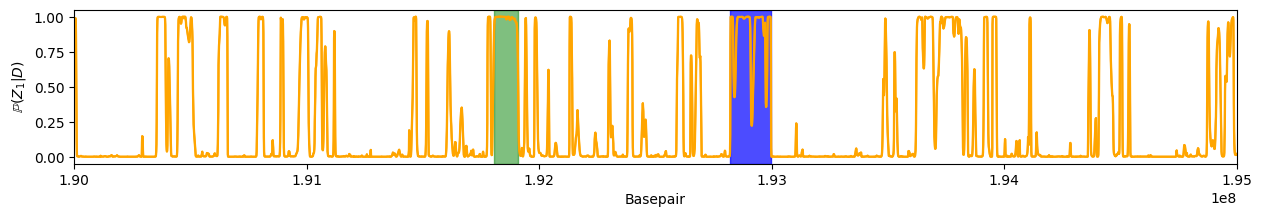

In [28]:
df = pd.read_csv("results/realdata/1000g_hg38_2022/hmmix/02decode/HG00096.hap1.txt", sep="\s+")
df['end'] = df['end'] + 1000
#dff = df[(df["chrom"] == "chr1") & (df["start"] >= 150000000) & (df["end"] < 200000000) & (df["state"] == "Archaic")]
dff = df[(df["chrom"] == "chr1") & (df["state"] == "Archaic") & (df["end"] + 1000 - df["start"] > 10e4) & (df["mean_prob"] > 0.8)]
hmmix = dff[['start', 'end']].to_numpy()
fig, ax = plt.subplots(1,1, figsize=(15,2))
ax.plot(treespan_phy, gammas[1], color = 'orange')
for x in hmmix:
    ax.axvspan(x[0], x[1], alpha=0.7, color='blue')
ax.set_xlabel(r'Basepair')
ax.set_ylabel(r'$\mathbb{P}(Z_1 | D)$')
ax.set_xlim(1.9e8, 1.95e8)
inferred, states = Performance_utils().filter_hmm_output(arc_cutoff=0.5,
            pp_cutoff=0.9,
            l_cutoff=10e4,
            popmerge=False,
            maxlen=None,
            combined_pp=gammas,
            treespan=treespan_phy)
infer = []
genetic_dis = []
filseg = np.zeros(states.shape[1])
for i, x in enumerate(inferred[1]):
    w = np.where(treespan_phy == np.array(x))[0]
    filseg[w[0]:(w[1] + 1)] = i
    genetic_dis.append(treespan[w[1]][1] - treespan[w[0]][0])
genetic_dis = np.array(genetic_dis)
indices = np.where(genetic_dis > 0.05)[0]
for x in indices:
    infer.append(inferred[1][x])
for x in infer:
    ax.axvspan(x[0], x[1], alpha=0.5, color='green')
pre, rec, _, _, _, _ = Performance_utils().calculate_performance(np.array(infer), hmmix)
print(pre, rec)

In [26]:
len(infer)

29

In [25]:
infer, hmmix

([(11572000, 11634000),
  (21957000, 22021000),
  (42943000, 43009000),
  (52987000, 53072000),
  (55569000, 55630000),
  (57907000, 57970000),
  (61020000, 61226000),
  (79117000, 79205000),
  (102987000, 103089000),
  (115841000, 115923000),
  (117637000, 117736000),
  (157303000, 157364000),
  (188687000, 188746000),
  (191807000, 191910000),
  (192849000, 192911000),
  (193724000, 193821000),
  (205510000, 205574000),
  (210487000, 210569000),
  (210600000, 210681000),
  (212647000, 212927000),
  (213533000, 213662000),
  (214924000, 214978000),
  (220931000, 221025000),
  (223465000, 223515000),
  (227069000, 227384000),
  (232051000, 232133000),
  (232819000, 232923000),
  (234620000, 234676000),
  (247183000, 247252000)],
 array([[ 11591000,  11648000],
        [ 15171000,  15240000],
        [ 21498000,  21632000],
        [ 38980000,  39069000],
        [ 46481000,  46543000],
        [ 46746000,  46812000],
        [ 47269000,  47345000],
        [ 49791000,  49853000],
     

In [22]:
df = pd.read_csv("/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/results/realdata/1000g_hg38_2022/ibdmix/ibdmix/EUR/altai_chr1.txt", sep="\s+")
dff = df[(df['ID']== 'HG00096') & (df['chrom'] == 'chr1') & (df['end'] - df['start'] > 5e4)]
dff = dff.sort_values(by='start')
dff[-30:]

,ID,chrom,start,end,slod
150293,HG00096,chr1,187882531,187934667,29.57630
151985,HG00096,chr1,188662474,188742833,30.74580
152338,HG00096,chr1,189644151,189702738,16.10810
156461,HG00096,chr1,192821541,192998055,122.10400
157071,HG00096,chr1,193730370,193808722,30.39190
158375,HG00096,chr1,194281307,194544262,154.27900
160318,HG00096,chr1,196201322,196608860,198.59700
163007,HG00096,chr1,199317849,200064641,293.53700
165657,HG00096,chr1,203929825,203984575,4.03621
168786,HG00096,chr1,205514738,205569790,38.38460


In [8]:
data = np.load("singerGBRaveFullMask20_t150000.chr1_0_249900000.xss.npz")
params = data['params']
df = pd.DataFrame(params, columns=['iter', 'loglik', 'p', 'q', 'pi0', 'a1', 'b1', 'a2', 'b2'])
df = df[~(df == 0).all(axis=1)]
df

,iter,loglik,p,q,pi0,a1,b1,a2,b2
0,0.0,-5.089821e+06,0.010000,0.100000,0.980814,0.766379,0.000007,1.085425,7.287860e-07
1,1.0,-5.080058e+06,0.009189,0.172121,0.985190,0.766379,0.000007,1.085425,1.475331e-06
2,2.0,-5.077311e+06,0.012742,0.143146,0.986233,0.766379,0.000007,1.066613,1.833623e-06
3,3.0,-5.075448e+06,0.014700,0.125162,0.987671,0.766379,0.000007,1.128099,2.183481e-06
4,4.0,-5.074124e+06,0.015644,0.116327,0.989337,0.766379,0.000007,1.206983,2.500100e-06
5,5.0,-5.073217e+06,0.016165,0.112223,0.990982,0.766379,0.000007,1.285600,2.774238e-06
6,6.0,-5.072633e+06,0.016505,0.110899,0.992468,0.766379,0.000007,1.357866,3.004639e-06
7,7.0,-5.072282e+06,0.016756,0.111283,0.993741,0.766379,0.000007,1.421929,3.193999e-06
8,8.0,-5.072092e+06,0.016956,0.112715,0.994799,0.766379,0.000007,1.477545,3.346831e-06
9,9.0,-5.072009e+06,0.017121,0.114763,0.995662,0.766379,0.000007,1.525116,3.468255e-06


0.0 143331.9621087013 18954.12704396372 17712.27905522865


Text(0.5, 1.0, 't_archaic')

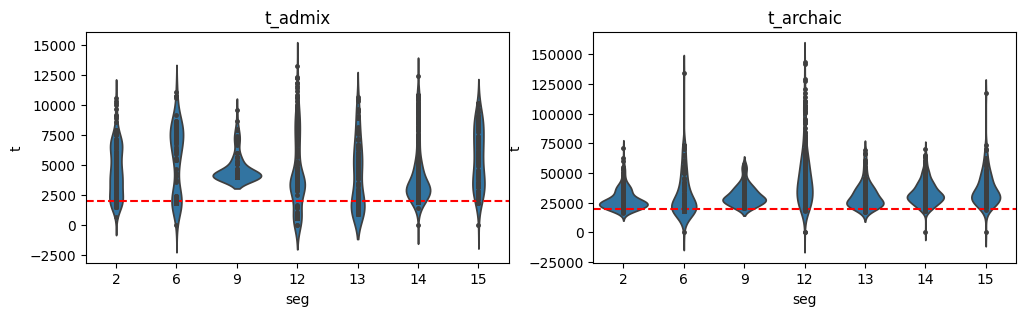

In [9]:
dfc1 = data['t1s'][states[1].astype(bool)].tolist() + data['t2s'][states[1].astype(bool)].tolist()
# jiggle the values randomly
# dfc1 = np.random.normal(loc=dfc1, scale=10)
print(np.min(dfc1), np.max(dfc1), np.mean(dfc1), np.std(dfc1))
dfc2 = ['t_admix'] * len(data['t1s'][states[1].astype(bool)]) + ['t_archaic'] * len(data['t2s'][states[1].astype(bool)])
dfc3 = filseg[states[1].astype(bool)].tolist() + filseg[states[1].astype(bool)].tolist()
dictdf = {'t': dfc1, 'type': dfc2, "seg": dfc3}
df = pd.DataFrame(dictdf)
df['seg'] = df['seg'].astype(int)
df = df[df['seg'].isin(indices)]
fig, ax = plt.subplots(1,2, figsize=(12,3))
sns.violinplot(data=df[df['type']=='t_admix'], x='seg', y='t', ax=ax[0], inner="point")
sns.violinplot(data=df[df['type']=='t_archaic'], x='seg', y='t', ax=ax[1], inner="point")
ax[1].axhline(y=20000, color='r', linestyle='--')
ax[0].axhline(y=2000, color='r', linestyle='--')
ax[0].set_title('t_admix')
ax[1].set_title('t_archaic')

IndexError: index 7 is out of bounds for axis 0 with size 7

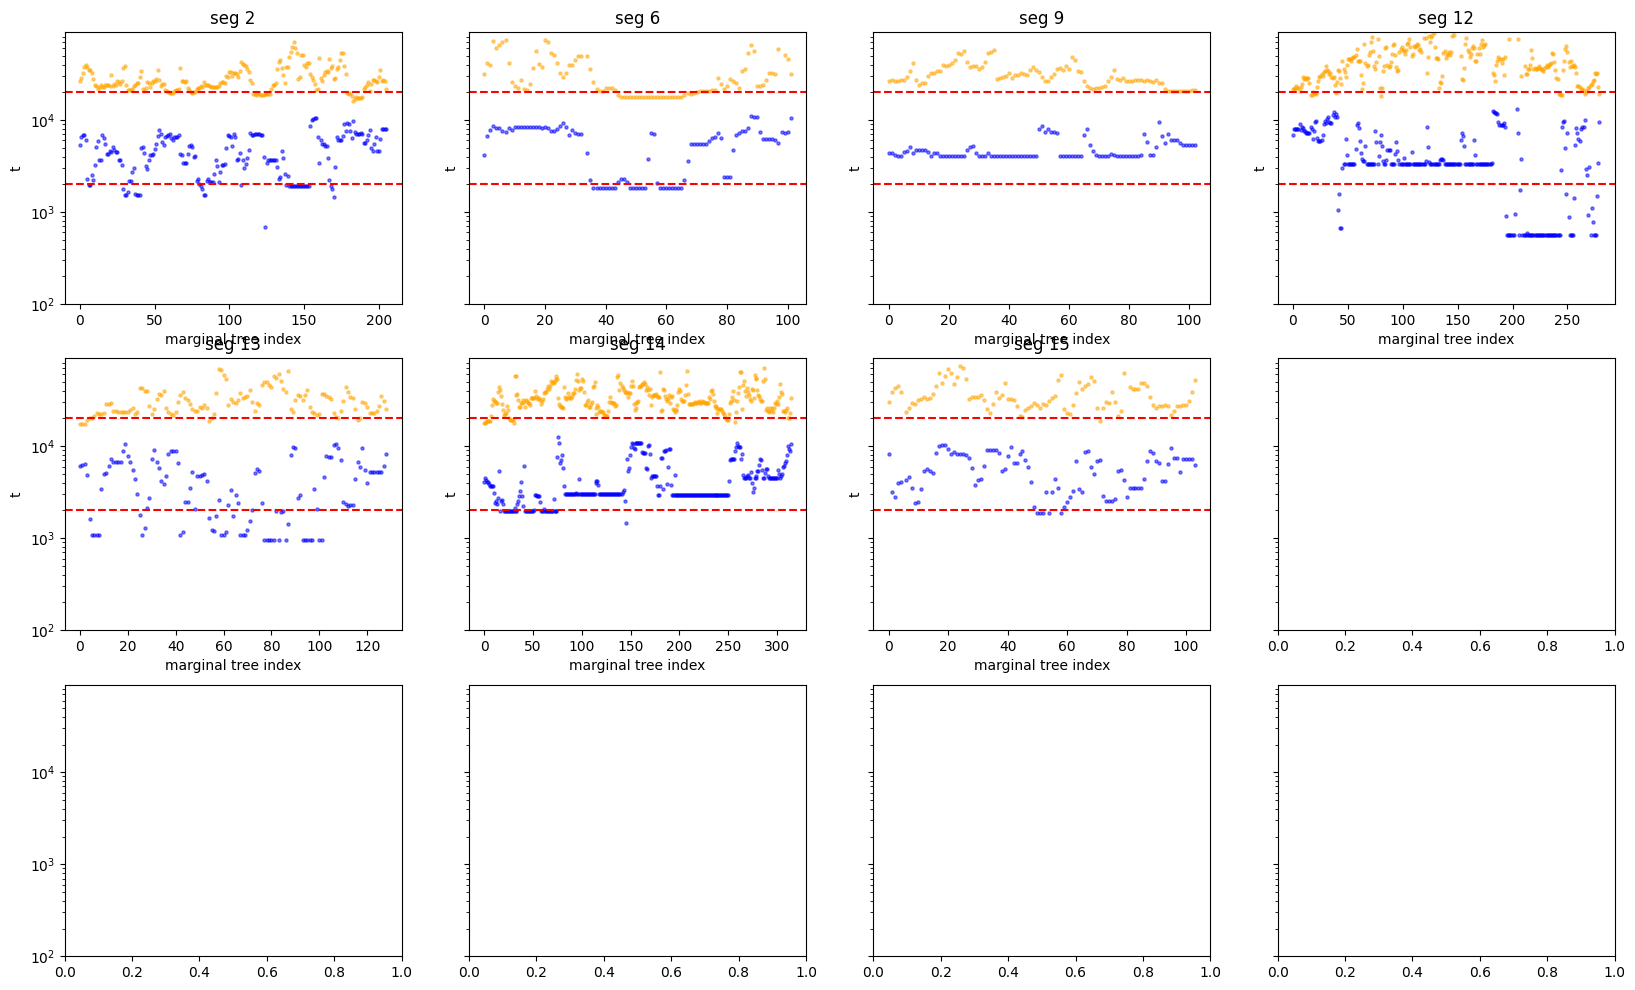

In [10]:
fig, ax = plt.subplots(3, 4, figsize=(20, 12), sharey=True)

for i in range(3):
    for j in range(4):
        ax[i][j].scatter(range(len(df[(df['seg'] == indices[int(4*i + j)]) & (df['type'] == 't_admix')])), df[(df['seg'] ==indices[int(4*i + j)]) & (df['type'] == 't_admix')]['t'], color='blue', alpha=0.5, label='t_admix', s = 5)
        ax[i][j].scatter(range(len(df[(df['seg'] == indices[int(4*i + j)]) & (df['type'] == 't_archaic')])), df[(df['seg'] == indices[int(4*i + j)]) & (df['type'] == 't_archaic')]['t'], color='orange', alpha=0.5, label='t_archaic', s = 5)
        ax[i][j].set_title(f'seg {indices[int(4*i + j)]}')
        ax[i][j].set_xlabel('marginal tree index')
        ax[i][j].set_ylabel('t')
        ax[i][j].set_yscale('log')
        ax[i][j].set_ylim(ymin = 1e2)
        ax[i][j].axhline(y=2000, color='r', linestyle='--')
        ax[i][j].axhline(y=20000, color='r', linestyle='--')

14054.183447060255 13885.429905621448
11130.291757655861 11794.112344954698
12326.950330688836 11947.954464689994


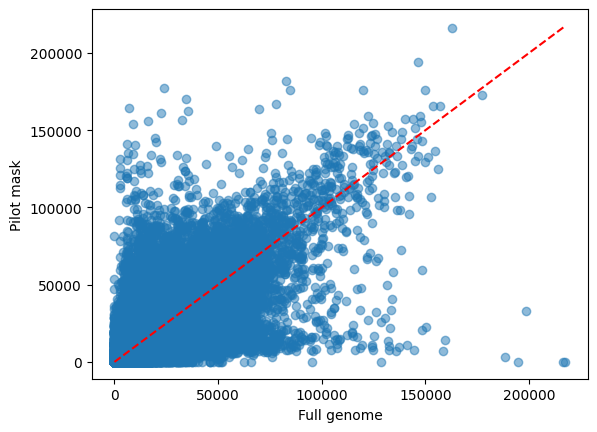

In [7]:
adata = np.load("results/realdata/1000g_hg38_2022/GhostHMM/singer_full/singerave_t15000_chr1_ind0.xss.npz")
bdata = np.load("results/realdata/1000g_hg38_2022/GhostHMM/singer_pilot_fullmu/singerave_t15000_chr1_ind0.xss.npz")
ancoal = adata['t2s'].mean(axis = 0) - adata['t1s']
bcoal = bdata['t2s'] - bdata['t1s']
plt.scatter(ancoal, bcoal, alpha=0.5)
plt.plot(range(int(np.max(ancoal))), range(int(np.max(ancoal))), color='red', linestyle='--')
plt.xlabel('Full genome')
plt.ylabel('Pilot mask')
print(np.mean(ancoal), np.mean(bcoal))
print(np.std(ancoal), np.std(bcoal))
print(np.median(ancoal), np.median(bcoal))

14317.080506579814 14333.866589558957
11066.114734354456 11129.116834341434
12524.518805353779 12526.61804031628


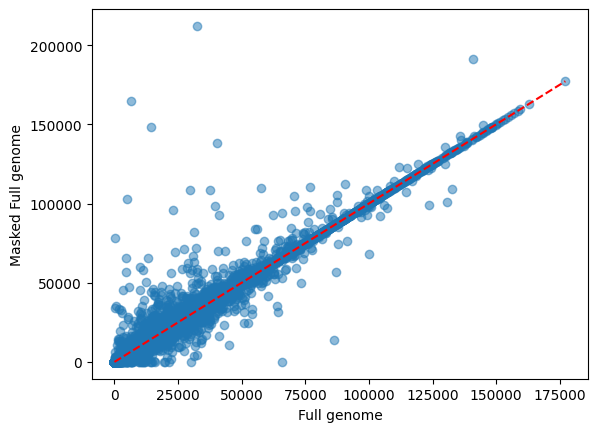

In [6]:
adata = np.load("singerGBRaveFull0.chr1_0_249900000.xss.npz")
bdata = np.load("singerGBRaveFullMask20_t150000.chr1_0_249900000.xss.npz")
ancoal = adata['t2s'] - adata['t1s']
bcoal = bdata['t2s'] - bdata['t1s']
bmask = bdata['accessible_windows'].astype(bool)
plt.scatter(ancoal[bmask], bcoal[bmask], alpha=0.5)
plt.plot(range(int(np.max(ancoal[bmask]))), range(int(np.max(ancoal[bmask]))), color='red', linestyle='--')
plt.xlabel('Full genome')
plt.ylabel('Masked Full genome')
print(np.mean(ancoal[bmask]), np.mean(bcoal[bmask]))
print(np.std(ancoal[bmask]), np.std(bcoal[bmask]))
print(np.median(ancoal[bmask]), np.median(bcoal[bmask]))

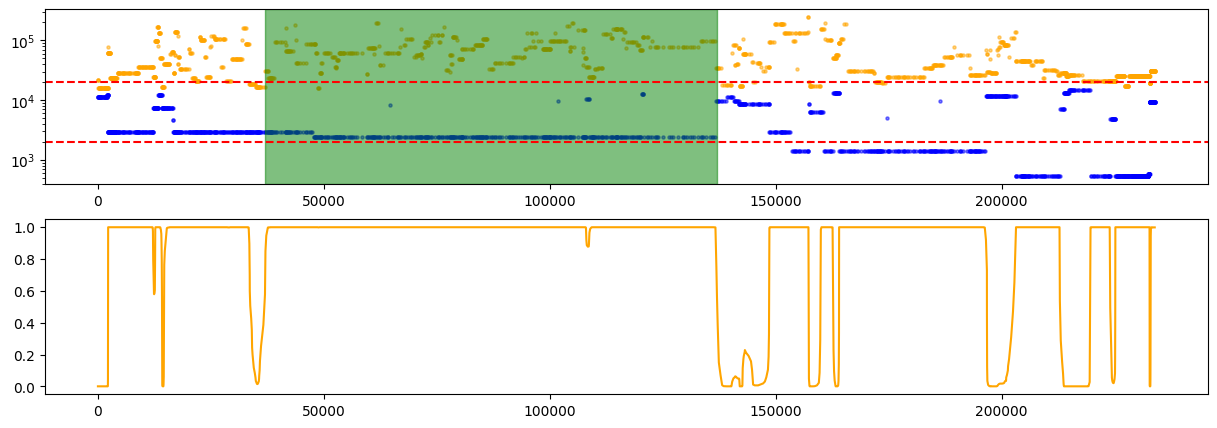

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
overlap = infer[9]
filseg = np.zeros(states.shape[1])
x = np.array(hmmix[hmmix[:, 0] > 2.125e8][0])
w = np.where((treespan_phy[:, 0] >= x[0]) & (treespan_phy[:, 0] < x[1]))[0]
filseg[w[0]:(w[-1] + 1)] = 1
dfc1 = data['t1s'][filseg.astype(bool)].tolist() + data['t2s'][filseg.astype(bool)].tolist()
dfc2 = ['t_admix'] * len(data['t1s'][filseg.astype(bool)]) + ['t_archaic'] * len(data['t2s'][filseg.astype(bool)])
dictdf = {'t': dfc1, 'type': dfc2}
df = pd.DataFrame(dictdf)
ax[0].scatter((treespan_phy[w] - treespan_phy[w[0], 0]).mean(axis=1), df[df['type'] == 't_admix']['t'], color='blue', alpha=0.5, label='t_admix', s = 5)
ax[0].scatter((treespan_phy[w] - treespan_phy[w[0], 0]).mean(axis=1), df[df['type'] == 't_archaic']['t'], color='orange', alpha=0.5, label='t_archaic', s = 5)
ax[0].set_yscale('log')
ax[0].axhline(y=2000, color='red', linestyle='--')
ax[0].axhline(y=20000, color='red', linestyle='--')
w2 = np.where((treespan_phy[:, 0] >= overlap[0]) & (treespan_phy[:, 0] < overlap[1]))[0]
ax[0].axvspan(treespan_phy[w2[0]][0] - treespan_phy[w[0], 0], treespan_phy[w2[-1]][1] - treespan_phy[w[0], 0], alpha=0.5, color='green')
ax[1].plot((treespan_phy[w] - treespan_phy[w[0], 0]).mean(axis=1), gammas[1, w], color='orange')

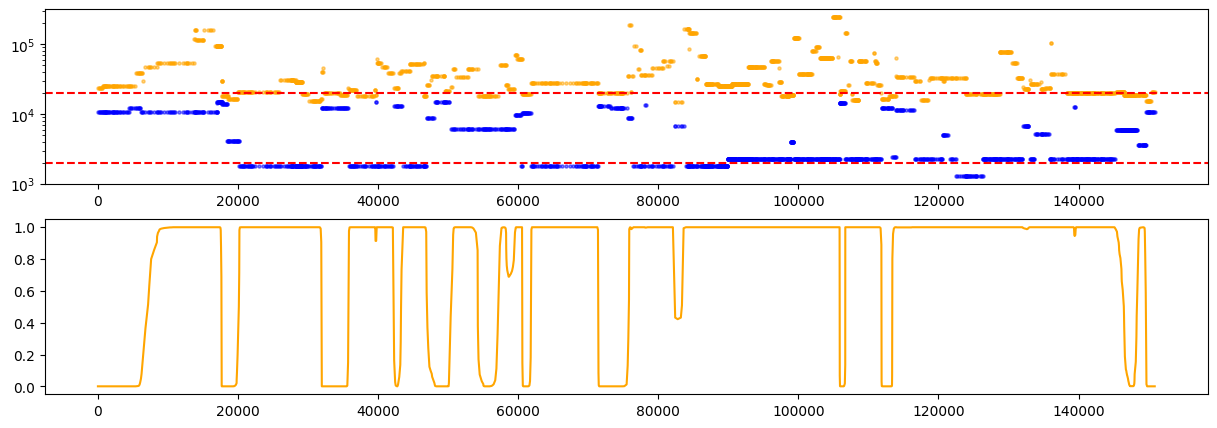

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
filseg = np.zeros(states.shape[1])
x = np.array(hmmix[hmmix[:, 0] > 2.125e8][1])
w = np.where((treespan_phy[:, 0] >= x[0]) & (treespan_phy[:, 0] < x[1]))[0]
filseg[w[0]:(w[-1] + 1)] = 1
dfc1 = data['t1s'][filseg.astype(bool)].tolist() + data['t2s'][filseg.astype(bool)].tolist()
dfc2 = ['t_admix'] * len(data['t1s'][filseg.astype(bool)]) + ['t_archaic'] * len(data['t2s'][filseg.astype(bool)])
dictdf = {'t': dfc1, 'type': dfc2}
df = pd.DataFrame(dictdf)
ax[0].scatter((treespan_phy[w] - treespan_phy[w[0], 0]).mean(axis=1), df[df['type'] == 't_admix']['t'], color='blue', alpha=0.5, label='t_admix', s = 5)
ax[0].scatter((treespan_phy[w] - treespan_phy[w[0], 0]).mean(axis=1), df[df['type'] == 't_archaic']['t'], color='orange', alpha=0.5, label='t_archaic', s = 5)
ax[0].set_yscale('log')
ax[0].axhline(y=2000, color='red', linestyle='--')
ax[0].axhline(y=20000, color='red', linestyle='--')
ax[1].plot((treespan_phy[w] - treespan_phy[w[0], 0]).mean(axis=1), gammas[1, w], color='orange')

# YRI

In [24]:
df = pd.read_csv("singerYRI316.posteriorProb.chr1_0_249900000.txt", sep="\t")
#dff = df[(df["chromosome"] == 1) & (df["start(physical)"] >= 150000000) & (df["end(physical)"] < 200000000)]
gammas = df[['Human', 'Archaic']].to_numpy().T
treespan = df[['start(cM)', 'end(cM)']].values
treespan_phy = df[['start(physical)', 'end(physical)']].values
print(gammas.shape, treespan.shape, treespan_phy.shape)
inferred, _ = Performance_utils().filter_hmm_output(arc_cutoff=0.9,
            pp_cutoff=0.9,
            l_cutoff=5e4,
            popmerge=False,
            maxlen=None,
            combined_pp=gammas,
            treespan=treespan_phy)
inferred[1], [x[1] - x[0] for x in inferred[1]]

(2, 2107507) (2107507, 2) (2107507, 2)


([(40175123, 40263195),
  (87009533, 87069067),
  (106354743, 106405634),
  (221593554, 221655621),
  (224905831, 224980278),
  (224991454, 225059509)],
 [88072, 59534, 50891, 62067, 74447, 68055])

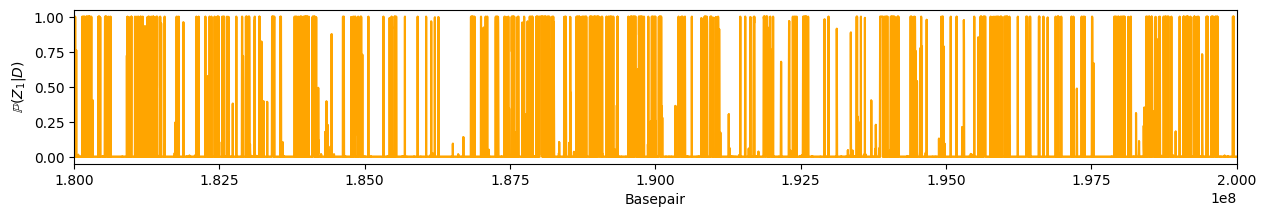

In [25]:
fig, ax = plt.subplots(1,1, figsize=(15,2))
ax.plot(treespan_phy, gammas[1], color = 'orange')
ax.set_xlabel(r'Basepair')
ax.set_ylabel(r'$\mathbb{P}(Z_1 | D)$')
ax.set_xlim(1.8e8, 2e8)
inferred, states = Performance_utils().filter_hmm_output(arc_cutoff=0.9,
            pp_cutoff=0.9,
            l_cutoff=5e4,
            popmerge=False,
            maxlen=None,
            combined_pp=gammas,
            treespan=treespan_phy)
infer = []
filseg = np.zeros(states.shape[1])
for i, x in enumerate(inferred[1]):
    w = np.where(treespan_phy == np.array(x))[0]
    filseg[w[0]:(w[1] + 1)] = i
    infer.append([treespan_phy[w[0]][0], treespan_phy[w[1]][1]])
    ax.axvspan(treespan_phy[w[0]][0], treespan_phy[w[1]][1], alpha=0.5, color='green')

In [26]:
data = np.load("singerYRI316.chr1_0_249900000.0.xss.npz")
params = data['params']
df = pd.DataFrame(params, columns=['iter', 'loglik', 'p', 'q', 'pi0', 'a1', 'b1', 'a2', 'b2'])
df = df[~(df == 0).all(axis=1)]
df

,iter,loglik,p,q,pi0,a1,b1,a2,b2
0,0.0,-4.347329e+07,0.010000,0.100000,0.049375,0.396717,0.000002,1.140048,2.284688e-07
1,1.0,-4.337001e+07,0.003827,0.033649,0.968136,0.396717,0.000002,1.140048,3.802903e-07
2,2.0,-4.336078e+07,0.003848,0.026614,0.999966,0.396717,0.000002,1.054245,4.134517e-07
3,3.0,-4.335907e+07,0.004016,0.025149,1.000000,0.396717,0.000002,1.047073,4.391775e-07
4,4.0,-4.335835e+07,0.004108,0.024755,1.000000,0.396717,0.000002,1.063347,4.576171e-07
5,5.0,-4.335792e+07,0.004146,0.024697,1.000000,0.396717,0.000002,1.084198,4.702184e-07
6,6.0,-4.335765e+07,0.004159,0.024751,1.000000,0.396717,0.000002,1.102897,4.785770e-07
7,7.0,-4.335751e+07,0.004161,0.024831,1.000000,0.396717,0.000002,1.117617,4.840122e-07
8,8.0,-4.335744e+07,0.004159,0.024905,1.000000,0.396717,0.000002,1.128445,4.874950e-07
9,9.0,-4.335740e+07,0.004155,0.024964,1.000000,0.396717,0.000002,1.136080,4.897003e-07


0.0 267646.16074267094 24801.04782359057 35014.85793113004


Text(0.5, 1.0, 't_archaic')

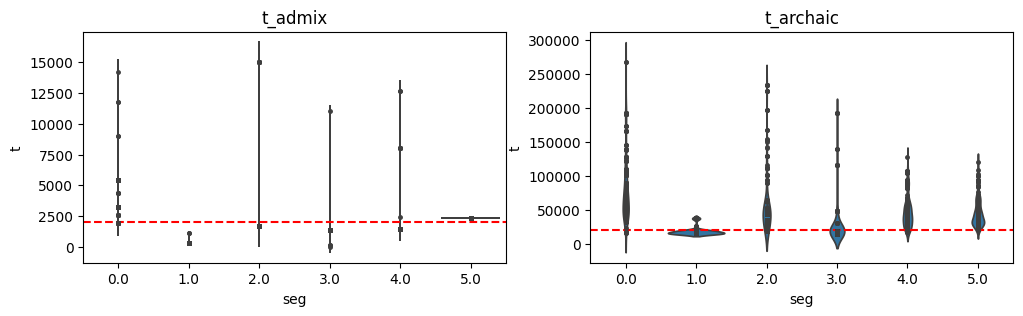

In [27]:
dfc1 = data['t1s'][states[1].astype(bool)].tolist() + data['t2s'][states[1].astype(bool)].tolist()
print(np.min(dfc1), np.max(dfc1), np.mean(dfc1), np.std(dfc1))
dfc2 = ['t_admix'] * len(data['t1s'][states[1].astype(bool)]) + ['t_archaic'] * len(data['t2s'][states[1].astype(bool)])
dfc3 = filseg[states[1].astype(bool)].tolist() + filseg[states[1].astype(bool)].tolist()
dictdf = {'t': dfc1, 'type': dfc2, "seg": dfc3}
df = pd.DataFrame(dictdf)
fig, ax = plt.subplots(1,2, figsize=(12,3))
sns.violinplot(data=df[df['type']=='t_admix'], x='seg', y='t', ax=ax[0], inner="point")
sns.violinplot(data=df[df['type']=='t_archaic'], x='seg', y='t', ax=ax[1], inner="point")
ax[1].axhline(y=20000, color='r', linestyle='--')
ax[0].axhline(y=2000, color='r', linestyle='--')
ax[0].set_title('t_admix')
ax[1].set_title('t_archaic')

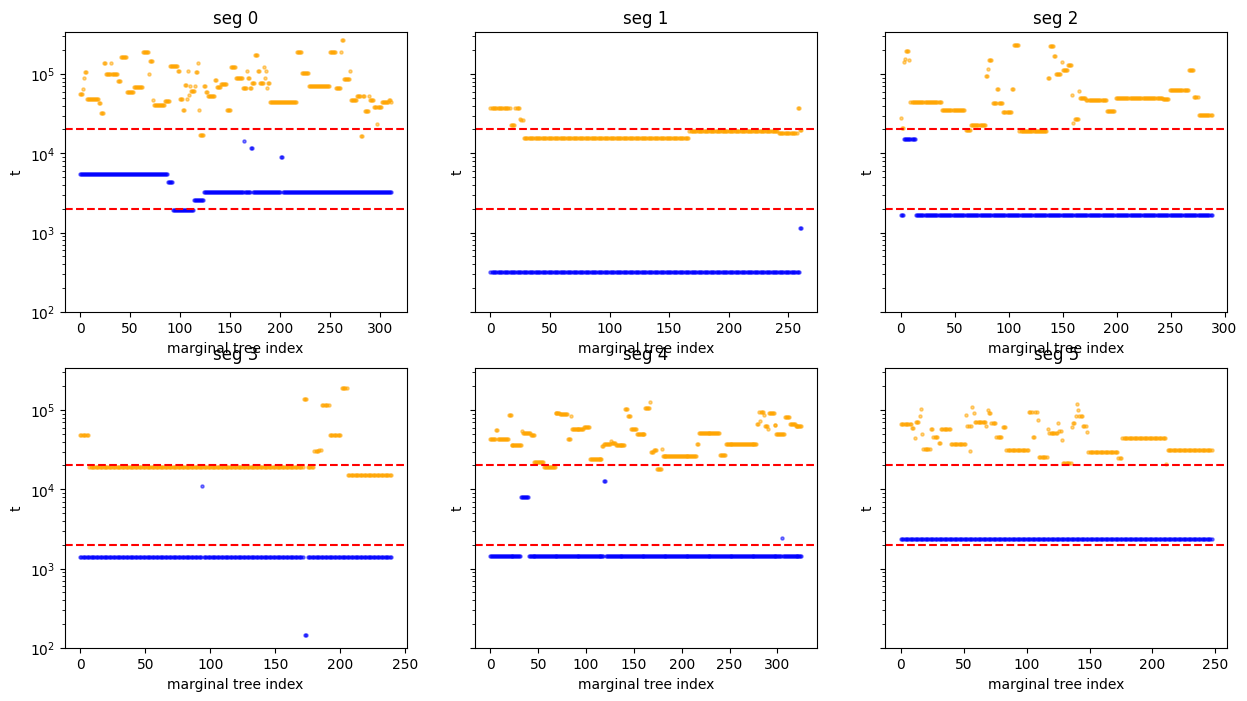

In [36]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for i in range(2):
    for j in range(3):
        ax[i][j].scatter(range(len(df[(df['seg'] == int(3*i + j)) & (df['type'] == 't_admix')])), df[(df['seg'] == int(3*i + j)) & (df['type'] == 't_admix')]['t'], color='blue', alpha=0.5, label='t_admix', s = 5)
        ax[i][j].scatter(range(len(df[(df['seg'] == int(3*i + j)) & (df['type'] == 't_archaic')])), df[(df['seg'] == int(3*i + j)) & (df['type'] == 't_archaic')]['t'], color='orange', alpha=0.5, label='t_archaic', s = 5)
        ax[i][j].set_title(f'seg {int(3*i + j)}')
        ax[i][j].set_xlabel('marginal tree index')
        ax[i][j].set_ylabel('t')
        ax[i][j].set_yscale('log')
        ax[i][j].set_ylim(ymin = 1e2)
        ax[i][j].axhline(y=2000, color='r', linestyle='--')
        ax[i][j].axhline(y=20000, color='r', linestyle='--')

# Consin's model

In [42]:
df = pd.read_csv("singerYRIarc316.posteriorProb.chr1_0_249900000.txt", sep="\t")
#dff = df[(df["chromosome"] == 1) & (df["start(physical)"] >= 150000000) & (df["end(physical)"] < 200000000)]
gammas = df[['Human', 'Archaic']].to_numpy().T
treespan = df[['start(cM)', 'end(cM)']].values
treespan_phy = df[['start(physical)', 'end(physical)']].values
print(gammas.shape, treespan.shape, treespan_phy.shape)
inferred, _ = Performance_utils().filter_hmm_output(arc_cutoff=0.9,
            pp_cutoff=0.9,
            l_cutoff=2e4,
            popmerge=False,
            maxlen=None,
            combined_pp=gammas,
            treespan=treespan_phy)
inferred[1]

(2, 2107507) (2107507, 2) (2107507, 2)


[(40181927, 40209340),
 (40225172, 40257611),
 (75742029, 75763170),
 (82677573, 82702898),
 (102690258, 102710266),
 (159488973, 159509195),
 (195096503, 195118513),
 (241750004, 241770373)]

In [43]:
data = np.load("singerYRIarc316.chr1_0_249900000.0.xss.npz")
params = data['params']
df = pd.DataFrame(params, columns=['iter', 'loglik', 'p', 'q', 'pi0', 'a1', 'b1', 'a2', 'b2'])
df = df[~(df == 0).all(axis=1)]
df

,iter,loglik,p,q,pi0,a1,b1,a2,b2
0,0.0,1.413327e+07,0.010000,0.100000,0.038816,0.29763,0.000004,1.1,3.189336e-07
1,1.0,1.421373e+07,0.004876,0.057791,1.000000,0.29763,0.000004,1.1,5.548345e-07
2,2.0,1.422775e+07,0.005314,0.047729,1.000000,0.29763,0.000004,1.1,6.809588e-07
3,3.0,1.423047e+07,0.005677,0.045396,1.000000,0.29763,0.000004,1.1,7.412249e-07
4,4.0,1.423099e+07,0.005867,0.044620,1.000000,0.29763,0.000004,1.1,7.686028e-07
5,5.0,1.423109e+07,0.005954,0.044321,1.000000,0.29763,0.000004,1.1,7.805854e-07
6,6.0,1.423111e+07,0.005992,0.044199,1.000000,0.29763,0.000004,1.1,7.857515e-07
7,7.0,1.423111e+07,0.006009,0.044148,1.000000,0.29763,0.000004,1.1,7.879677e-07
8,8.0,1.423111e+07,0.006016,0.044126,1.000000,0.29763,0.000004,1.1,7.889167e-07
9,9.0,1.423111e+07,0.006019,0.044117,1.000000,0.29763,0.000004,1.1,7.893228e-07


(0.0, 1000000.0)

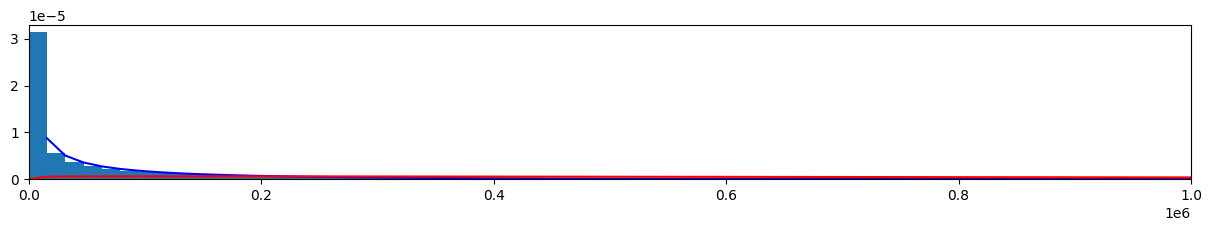

In [13]:
fig, ax = plt.subplots(1,1, figsize=(15,2))
ax.hist(data['ncoal'], bins=10000, density=True)
x = np.linspace(0, np.max(data['ncoal']), 10000)
y = stats.gamma.pdf(x, a = df.iloc[-1]['a1'], scale = 1/df.iloc[-1]['b1'])
y2 = stats.gamma.pdf(x, a = df.iloc[-1]['a2'], scale = 1/df.iloc[-1]['b2'])
ax.plot(x, y, color='blue')
ax.plot(x, y2, color='red')
ax.set_xlim(0, 1e6)

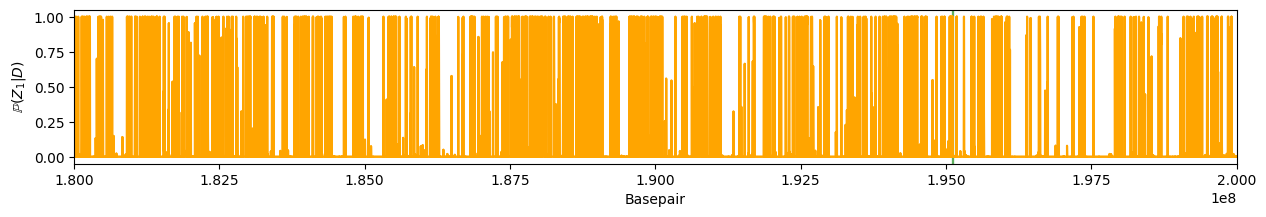

In [44]:
fig, ax = plt.subplots(1,1, figsize=(15,2))
ax.plot(treespan_phy, gammas[1], color = 'orange')
ax.set_xlabel(r'Basepair')
ax.set_ylabel(r'$\mathbb{P}(Z_1 | D)$')
ax.set_xlim(1.8e8, 2e8)
inferred, states = Performance_utils().filter_hmm_output(arc_cutoff=0.9,
            pp_cutoff=0.9,
            l_cutoff=2e4,
            popmerge=False,
            maxlen=None,
            combined_pp=gammas,
            treespan=treespan_phy)
infer = []
filseg = np.zeros(states.shape[1])
for i, x in enumerate(inferred[1]):
    w = np.where(treespan_phy == np.array(x))[0]
    filseg[w[0]:(w[1] + 1)] = i
    infer.append([treespan_phy[w[0]][0], treespan_phy[w[1]][1]])
    ax.axvspan(treespan_phy[w[0]][0], treespan_phy[w[1]][1], alpha=0.5, color='green')

1921.5446927838734 333096.02988419804 65289.88693233358 70459.35364114158


Text(0.5, 1.0, 't_archaic')

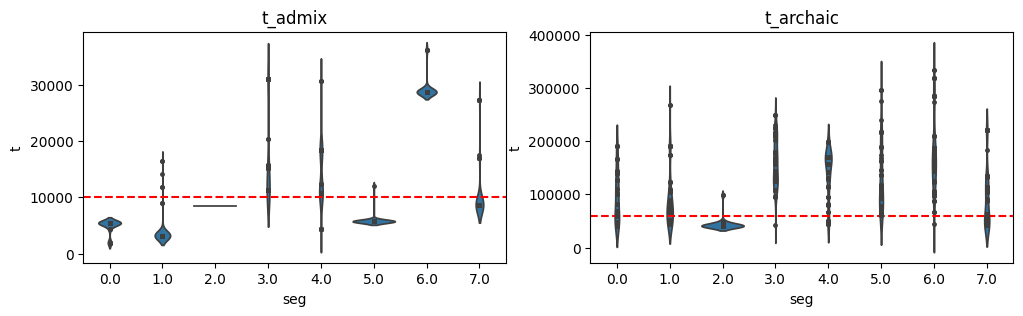

In [45]:
dfc1 = data['t1s'][states[1].astype(bool)].tolist() + data['t2s'][states[1].astype(bool)].tolist()
print(np.min(dfc1), np.max(dfc1), np.mean(dfc1), np.std(dfc1))
dfc2 = ['t_admix'] * len(data['t1s'][states[1].astype(bool)]) + ['t_archaic'] * len(data['t2s'][states[1].astype(bool)])
dfc3 = filseg[states[1].astype(bool)].tolist() + filseg[states[1].astype(bool)].tolist()
dictdf = {'t': dfc1, 'type': dfc2, "seg": dfc3}
df = pd.DataFrame(dictdf)
fig, ax = plt.subplots(1,2, figsize=(12,3))
sns.violinplot(data=df[df['type']=='t_admix'], x='seg', y='t', ax=ax[0], inner="point")
sns.violinplot(data=df[df['type']=='t_archaic'], x='seg', y='t', ax=ax[1], inner="point")
ax[1].axhline(y=60000, color='r', linestyle='--')
ax[0].axhline(y=10000, color='r', linestyle='--')
ax[0].set_title('t_admix')
ax[1].set_title('t_archaic')

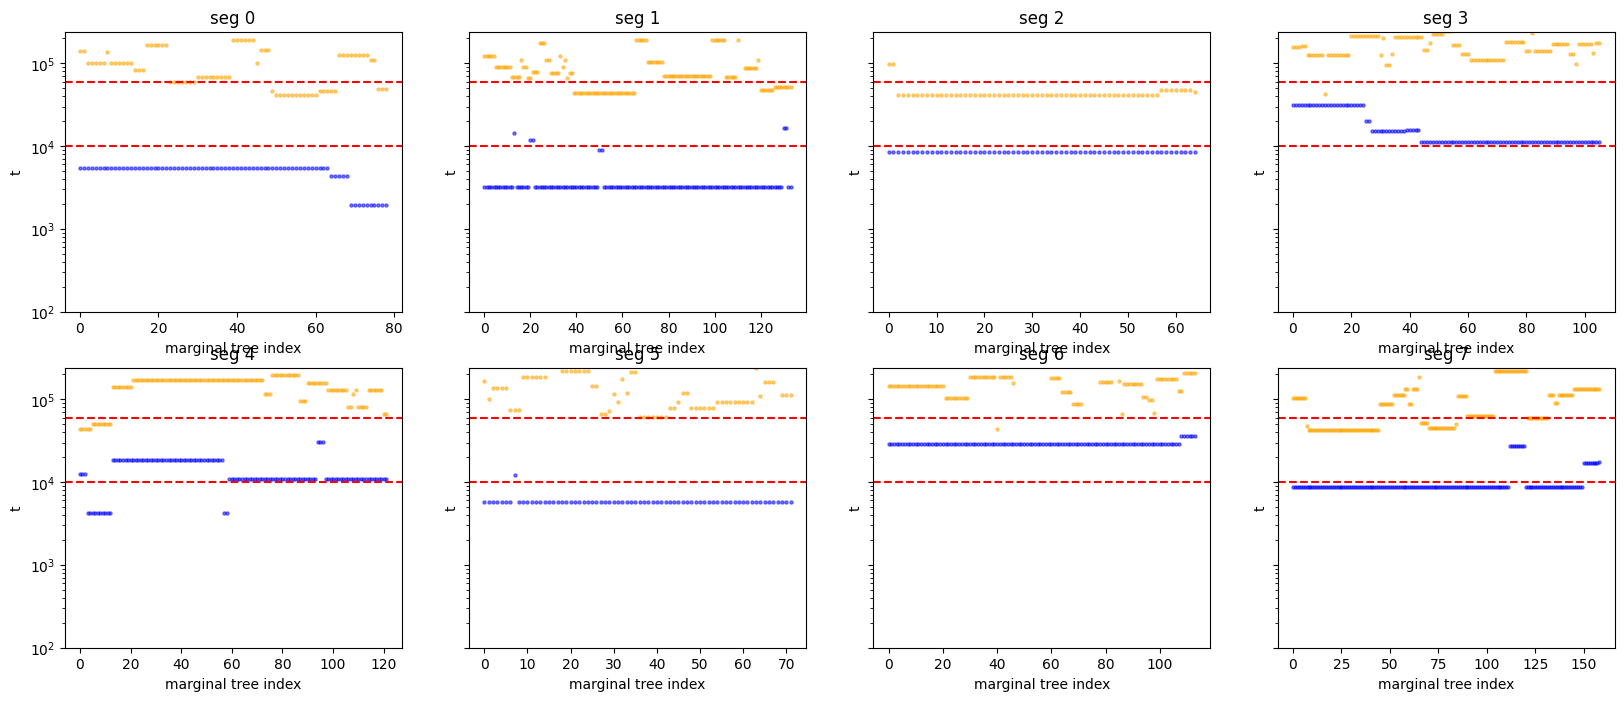

In [48]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8), sharey=True)

for i in range(2):
    for j in range(4):
        ax[i][j].scatter(range(len(df[(df['seg'] == int(4*i + j)) & (df['type'] == 't_admix')])), df[(df['seg'] == int(4*i + j)) & (df['type'] == 't_admix')]['t'], color='blue', alpha=0.5, label='t_admix', s = 5)
        ax[i][j].scatter(range(len(df[(df['seg'] == int(4*i + j)) & (df['type'] == 't_archaic')])), df[(df['seg'] == int(4*i + j)) & (df['type'] == 't_archaic')]['t'], color='orange', alpha=0.5, label='t_archaic', s = 5)
        ax[i][j].set_title(f'seg {int(4*i + j)}')
        ax[i][j].set_xlabel('marginal tree index')
        ax[i][j].set_ylabel('t')
        ax[i][j].set_yscale('log')
        ax[i][j].set_ylim(ymin = 1e2)
        ax[i][j].axhline(y=10000, color='r', linestyle='--')
        ax[i][j].axhline(y=60000, color='r', linestyle='--')